### KNN model 


### 1. Import Libraries

In [88]:
import pandas as pd
import numpy as np
import seaborn as sns 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


### 2. Load Dataset

In [89]:
df = pd.read_csv(r"C:\Users\Maftuna\Downloads\heart (1).csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [90]:
df['target'].unique().tolist()

[1, 0]

In [91]:
df['target'].value_counts()

target
1    165
0    138
Name: count, dtype: int64

### 3. Data Preprocessing

In [92]:
x = df.drop('target', axis = 1)
y = df['target']

In [93]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)

print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 13)
(61, 13)
(242,)
(61,)


### 4. Model training

In [94]:
# KNN modleini o'qitish

model = KNeighborsClassifier(n_neighbors = 3)
model.fit(x_train, y_train)

KNeighborsClassifier(n_neighbors=3)

### 5. Prediction

In [95]:
y_pred = model.predict(x_test)
y_pred

array([0, 1, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 1,
       1, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0], dtype=int64)

### 6. Evalution

In [96]:
accuracy = accuracy_score(y_test, y_pred)
print("Aniqlilik: ", accuracy)

print("\nKlassifikatsiya xisoboti:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))




Aniqlilik:  0.6557377049180327

Klassifikatsiya xisoboti:
              precision    recall  f1-score   support

           0       0.62      0.69      0.66        29
           1       0.69      0.62      0.66        32

    accuracy                           0.66        61
   macro avg       0.66      0.66      0.66        61
weighted avg       0.66      0.66      0.66        61

Confusion Matrix:
[[20  9]
 [12 20]]


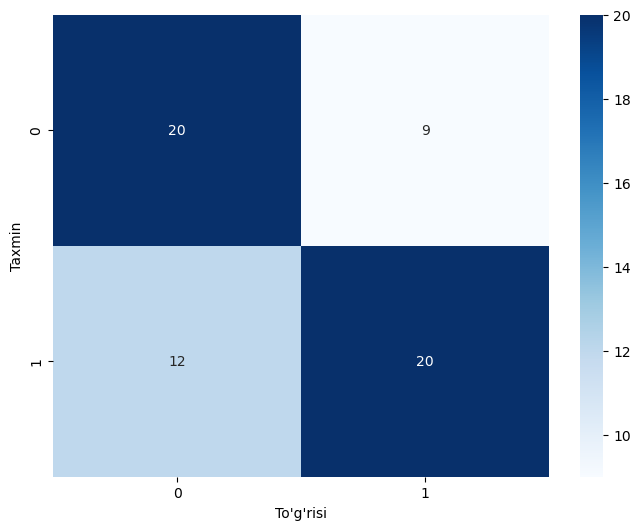

In [97]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6.))
sns.heatmap(cm, annot=True, fmt = 'd', cmap='Blues')
plt.xlabel("To'g'risi")
plt.ylabel("Taxmin")
plt.show()